In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("listings.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1524234450839767037,Back-yard glamping in a hilly village hideaway.,722218412.0,David,Waikato District,Ngaruawahia Ward,-37.672425,175.076133,Entire home/apt,NaN,1.0,0,NaN,NaN,1.0,365,0,NaN
1,786669704036257805,Nice n cosy,227570675.0,Shallu,Hamilton City,East Ward,-37.720780,175.268420,Entire home/apt,208.0,1.0,1,2022-12-28,0.02,3.0,364,0,NaN
2,11976654,Manorviews(Courtyard 1 Room),32717738.0,기홍,Waikato District,Huntly Ward,-37.563640,175.164560,Private room,105.0,1.0,1,2018-12-21,0.01,5.0,319,0,NaN
3,763997623901797190,Room in Matamata,161668156.0,Simranjot,Matamata-Piako District,Morrinsville Ward,-37.642997,175.528401,Private room,338.0,1.0,0,NaN,NaN,1.0,365,0,NaN
4,1288605849157597506,Brand New Room,371862492.0,Matt,Hamilton City,East Ward,-37.720899,175.278350,Private room,91.0,1.0,0,NaN,NaN,1.0,365,0,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50932 entries, 0 to 50931
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              50932 non-null  int64  
 1   name                            50932 non-null  object 
 2   host_id                         50931 non-null  float64
 3   host_name                       50926 non-null  object 
 4   neighbourhood_group             50932 non-null  object 
 5   neighbourhood                   50932 non-null  object 
 6   latitude                        50932 non-null  float64
 7   longitude                       50932 non-null  float64
 8   room_type                       50932 non-null  object 
 9   price                           45709 non-null  float64
 10  minimum_nights                  50924 non-null  float64
 11  number_of_reviews               50932 non-null  int64  
 12  last_review                     

In [4]:
df.shape

(50932, 18)

In [5]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               1
host_name                             6
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              5223
minimum_nights                        8
number_of_reviews                     0
last_review                        5128
reviews_per_month                  5128
calculated_host_listings_count        1
availability_365                      0
number_of_reviews_ltm                 0
license                           50932
dtype: int64

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,5.093200e+04,5.093100e+04,50932.000000,50932.000000,45709.000000,50924.000000,50932.000000,45804.000000,50931.000000,50932.000000,50932.000000,0.0
mean,8.358510e+17,6.582271e+15,-40.189985,173.489554,378.154937,2.103880,67.330166,1.750372,41.597043,206.501473,14.826317,NaN
std,6.348622e+17,1.051013e+17,3.356993,5.326943,685.468098,8.742389,115.817422,1.878552,185.958311,120.890182,20.682934,NaN
min,3.619400e+04,2.930000e+04,-46.906730,-176.561300,5.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,NaN
25%,4.514426e+07,6.001351e+07,-43.538043,172.578916,173.000000,1.000000,4.000000,0.420000,1.000000,93.000000,1.000000,NaN
50%,1.011999e+18,1.522532e+08,-39.339450,174.706190,264.000000,1.000000,22.000000,1.110000,2.000000,227.000000,7.000000,NaN
75%,1.397302e+18,3.749159e+08,-36.943621,175.393460,429.000000,2.000000,78.000000,2.412500,6.000000,320.000000,20.000000,NaN
max,1.710774e+18,1.710715e+18,-34.515710,178.486155,84438.000000,639.000000,1584.000000,24.720000,1215.000000,365.000000,267.000000,NaN


In [7]:
df.duplicated().sum()

np.int64(0)

In [76]:
numeric_cols = ['price', 'reviews_per_month', 'calculated_host_listings_count', 'host_id']
mean_values = df[numeric_cols].mean()
df[numeric_cols] = df[numeric_cols].fillna(value=mean_values)

df['last_review'] = df['last_review'].fillna('No Review Date')

all_cols = numeric_cols + ['last_review']
print(df[all_cols].isnull().sum())

price                             0
reviews_per_month                 0
calculated_host_listings_count    0
host_id                           0
last_review                       0
dtype: int64


In [16]:
df= df.fillna({
    'name': 'Unknown',
    'host_name': 'Unknown',
    'neighbourhood_group': 'Unknown',
    'neighbourhood': 'Unknown',
    'room_type': 'Unknown'
})
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1524234450839767037,Back-yard glamping in a hilly village hideaway.,722218412.0,David,Waikato District,Ngaruawahia Ward,-37.672425,175.076133,Entire home/apt,0.0,1.0,0,0,0.00,1.0,365,0,0.0
1,786669704036257805,Nice n cosy,227570675.0,Shallu,Hamilton City,East Ward,-37.720780,175.268420,Entire home/apt,208.0,1.0,1,2022-12-28,0.02,3.0,364,0,0.0
2,11976654,Manorviews(Courtyard 1 Room),32717738.0,기홍,Waikato District,Huntly Ward,-37.563640,175.164560,Private room,105.0,1.0,1,2018-12-21,0.01,5.0,319,0,0.0
3,763997623901797190,Room in Matamata,161668156.0,Simranjot,Matamata-Piako District,Morrinsville Ward,-37.642997,175.528401,Private room,338.0,1.0,0,0,0.00,1.0,365,0,0.0
4,1288605849157597506,Brand New Room,371862492.0,Matt,Hamilton City,East Ward,-37.720899,175.278350,Private room,91.0,1.0,0,0,0.00,1.0,365,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50927,672065698013169331,"Spacious, Modern 1 BD with Ens close to Remarks",24164764.0,Mishelle,Queenstown-Lakes District,Queenstown-Wakatipu Ward,-45.066500,168.749000,Private room,0.0,2.0,71,2026-04-09,1.49,1.0,0,30,0.0
50928,48290412,Cambridge Farm Cottage with view,12486629.0,Cj,Waipa District,Cambridge Ward,-37.854010,175.439450,Entire home/apt,142.0,1.0,295,2026-05-30,4.60,1.0,11,26,0.0
50929,993567873481058119,"Sumner Beach, 2 blocks to the surf!\nMonthly",4359511.0,Chris,Christchurch City,Heathcote Ward,-43.574279,172.765747,Entire home/apt,0.0,7.0,3,2024-06-06,0.11,1.0,0,0,0.0
50930,1554132490161207482,Cozy room,57358571.0,Marina,Queenstown-Lakes District,Queenstown-Wakatipu Ward,-45.006330,168.781840,Private room,0.0,1.0,2,2026-01-15,0.32,2.0,0,2,0.0


In [18]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
dtype: int64

# Pricing & Revenue Optimization

In [19]:
#What is the average and median price of an Airbnb listing across different neighborhood groups?
price_analysis= df.groupby('neighbourhood_group')['price'].agg(['count', 'mean', 'median']).reset_index()
price_analysis.columns= ['neighbourhood_group', 'total listings', 'average price', 'median price']
price_analysis = price_analysis.sort_values(by='average price', ascending= False)
print(price_analysis)

          neighbourhood_group  total listings  average price  median price
35  Queenstown-Lakes District            6450     620.139380         457.0
10         Far North District            1669     392.626723         246.0
18           Hurunui District             522     384.210728         367.0
11          Gisborne District             365     371.772603         244.0
25         Mackenzie District            1042     367.108445         338.0
..                        ...             ...            ...           ...
53       Waimakariri District             189     193.820106         166.0
51            Upper Hutt City             132     187.242424         159.0
44         Stratford District              54     186.351852         182.0
45           Tararua District              55     183.654545         171.0
23           Kawerau District               6     159.500000         115.0

[67 rows x 4 columns]


C:\Users\sudar\AppData\Local\Temp\ipykernel_27196\1182217493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


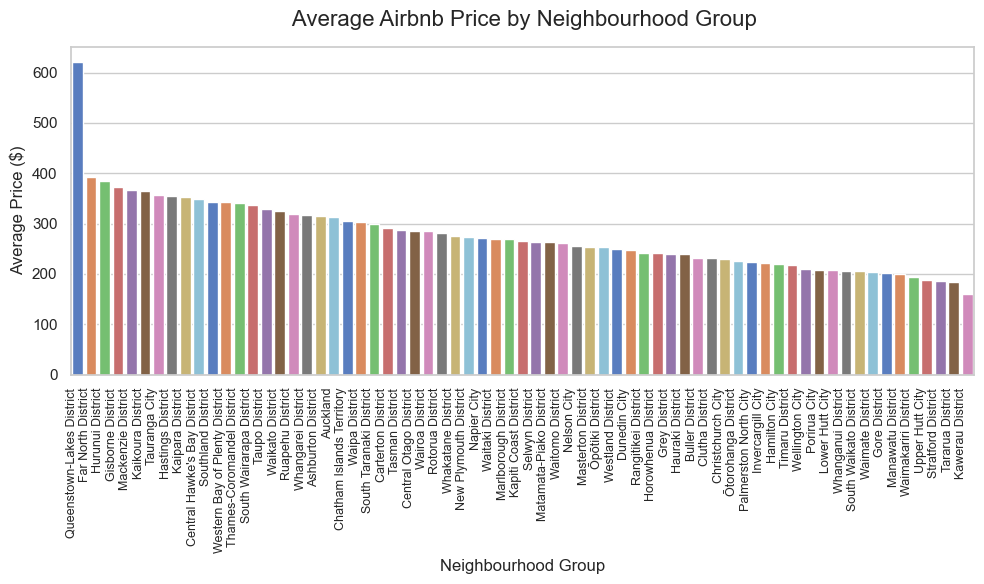

In [23]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=price_analysis,
    x= 'neighbourhood_group',
    y= 'average price',
    palette='muted'
)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.title (' Average Airbnb Price by Neighbourhood Group', fontsize= 16, pad=15)
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.tight_layout()

plt.show()


In [27]:
# What are the top 10 most expensive neighbourhoods vs the 10 cheapest neighbourhoods?
neighborhood_prices = df.groupby('neighbourhood')['price'].mean().reset_index()
neighborhood_prices = neighborhood_prices.rename(columns={'price': 'average_price'})
top_10_expensive = neighborhood_prices.sort_values(by='average_price', ascending=False).head(10)
top_10_cheapest = neighborhood_prices.sort_values(by='average_price', ascending=True).head(10)
print(" --- TOP 10 MOST EXPENSIVE NEIGHBOURHOODS ---")
print (top_10_expensive.to_string(index=False))

print("\n--- 10 CHEAPEST NEIGHBOURHOODS---")
print(top_10_cheapest.to_string(index=False))

 --- TOP 10 MOST EXPENSIVE NEIGHBOURHOODS ---
                neighbourhood  average_price
        Galatea-Murupara Ward     675.000000
     Queenstown-Wakatipu Ward     674.011010
               Arrowtown Ward     600.011583
                  Wanaka Ward     510.918033
        Hukanui-Waerenga Ward     498.000000
              Kahuranaki Ward     480.425806
Bay of Islands-Whangaroa Ward     461.370405
                Tamahere Ward     458.419355
       Taruheru-Patutahi Ward     451.884615
                  Rodney Ward     412.305065

--- 10 CHEAPEST NEIGHBOURHOODS---
                                  neighbourhood  average_price
                                   Burwood Ward     109.428571
                                Otorohanga Ward     126.000000
                                     Levin Ward     131.461538
                                 Ellesmere Ward     144.937500
                          Kiokio-Korakonui Ward     150.200000
                                   Mataura War

ValueError: Could not interpret value ` average price` for `x`. An entry with this name does not appear in `data`.

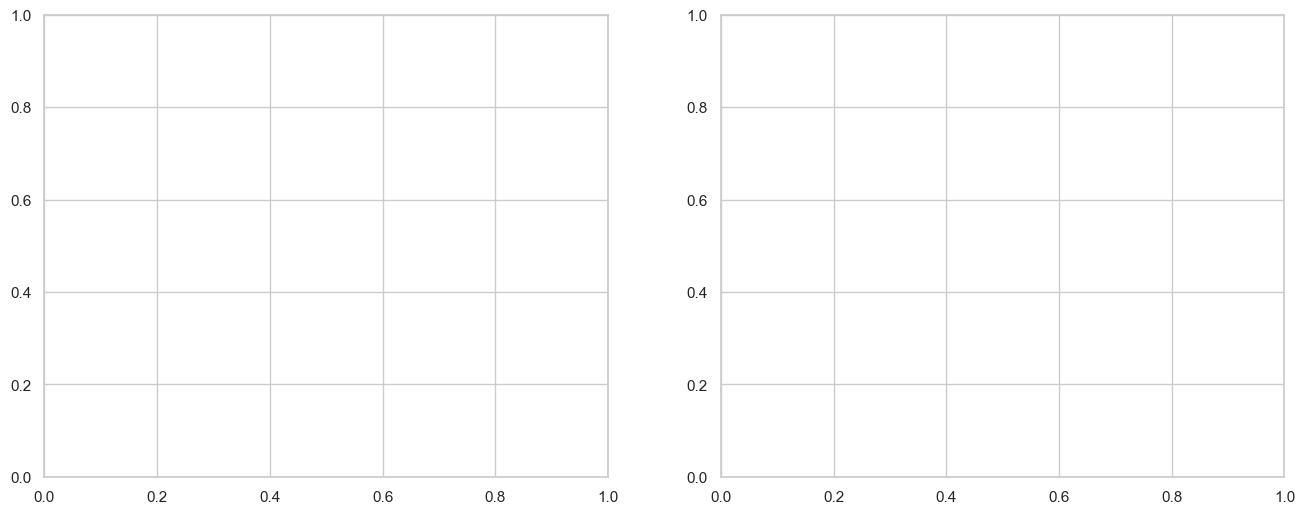

In [33]:
fig, axes = plt.subplots(1,2, figsize=(16, 6 ))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=top_10_expensive,
    x=' average price',
    y= 'neighbourhood',
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('TOP 10 MOST EXPENSIVE NEIGHBOURHOODS', fontsize=14, pad=10)
axes[0].set_xlabel(' Average price ($)')
axes[0].set_ylabel('Neighbourhood')

sns.barplot(
    data=top_10_cheapest,
    x= 'average price',
    y= ' neighbourhood',
    ax=axes[1],
    palette='Blues_r'
)

axes[1].set_title(' 10 CHEAPEST NEIGHBOURHOODS', fontsize=14, pad=10)
axes[1].set_xlabel(' AVERAGE PRICE($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [34]:
top_10_expensive.head()
top_10_cheapest.head()

,neighbourhood,average_price
14,Burwood Ward,109.428571
116,Otorohanga Ward,126.000000
70,Levin Ward,131.461538
30,Ellesmere Ward,144.937500
67,Kiokio-Korakonui Ward,150.200000


In [42]:
# Is there a major price difference between renting an Entire home/apt vs a Private room?

room_type_analysis = df.groupby('room_type')['price'].agg(['count', 'mean', 'median']).reset_index()
room_type_analysis.columns = ['Room Type', 'Total Lisitngs', 'Average Price', 'Median Price']
room_type_analysis = room_type_analysis.sort_values(by='Average Price', ascending=False)

print(room_type_analysis)

         Room Type  Total Lisitngs  Average Price  Median Price
0  Entire home/apt           41757     378.011974         277.0
1       Hotel room             168     256.196429         245.0
2     Private room            8859     163.228355         123.0
3      Shared room             148      76.736486          37.0


C:\Users\sudar\AppData\Local\Temp\ipykernel_27196\3373376878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


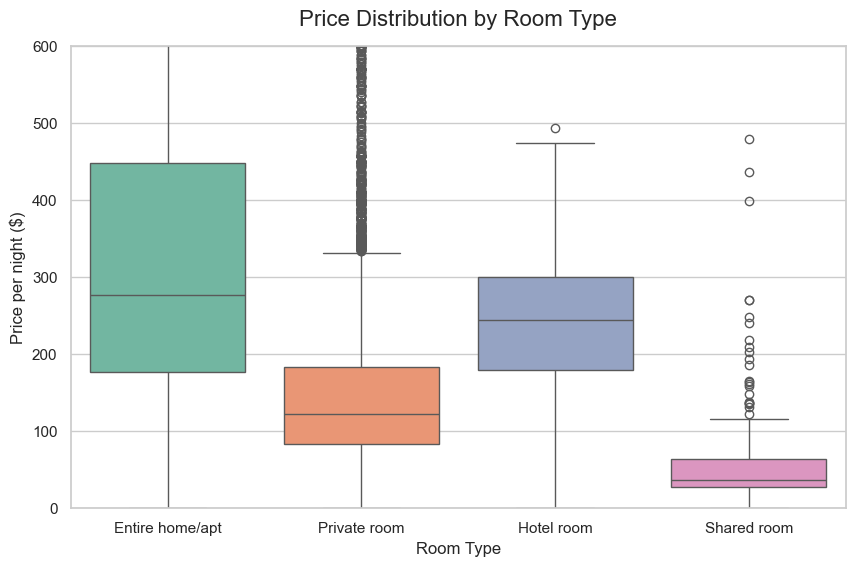

In [45]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df,
    x= 'room_type',
    y= 'price',
    palette= 'Set2'
)
# Fixing the outlier
plt.ylim(0,600)

plt.title('Price Distribution by Room Type', fontsize=16, pad=15)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Price per night ($)', fontsize=12)

plt.show()

# Geographical & Spatial Analysis

In [48]:
# Which neighbourhood group has the highest concenteration of active Airbnb listings?

counts = df['neighbourhood_group'].value_counts()

top_group = counts.index[0]
top_count = counts.iloc[0]

percentage = (top_count / len(df)) * 100

print(f" The neighbourhood group with the highest concentration is: {top_group}")
print(f" It has {top_count:,} active listings,which makes up {percentage:.1f}% of your entire dataset.")

 The neighbourhood group with the highest concentration is: Auckland
 It has 9,463 active listings,which makes up 18.6% of your entire dataset.


C:\Users\sudar\AppData\Local\Temp\ipykernel_27196\3202710463.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


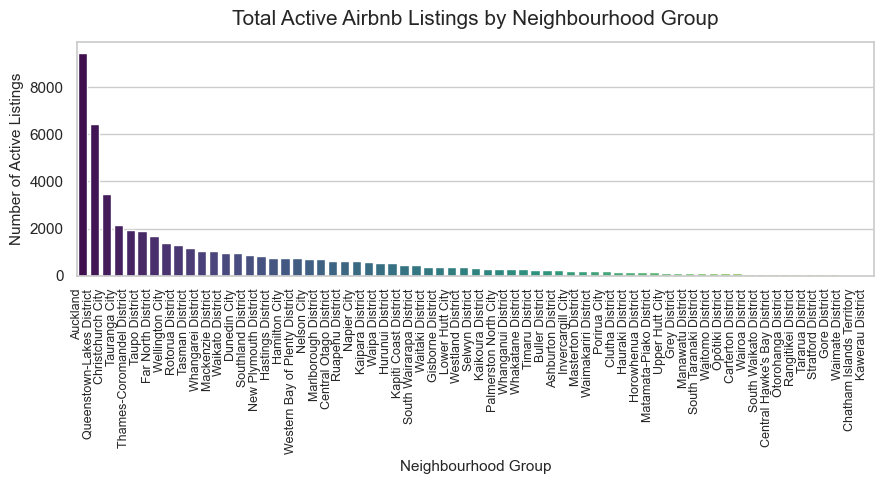

In [50]:
plt.figure(figsize=(9,5))
sns.set_theme(style="whitegrid")

sns.countplot(
    data= df,
    x= 'neighbourhood_group',
    order=df['neighbourhood_group'].value_counts().index,
    palette= 'viridis'
)

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.title('Total Active Airbnb Listings by Neighbourhood Group', fontsize=15, pad=12)
plt.xlabel('Neighbourhood Group', fontsize=11)
plt.ylabel('Number of Active Listings', fontsize=11)
plt.tight_layout()

plt.show()

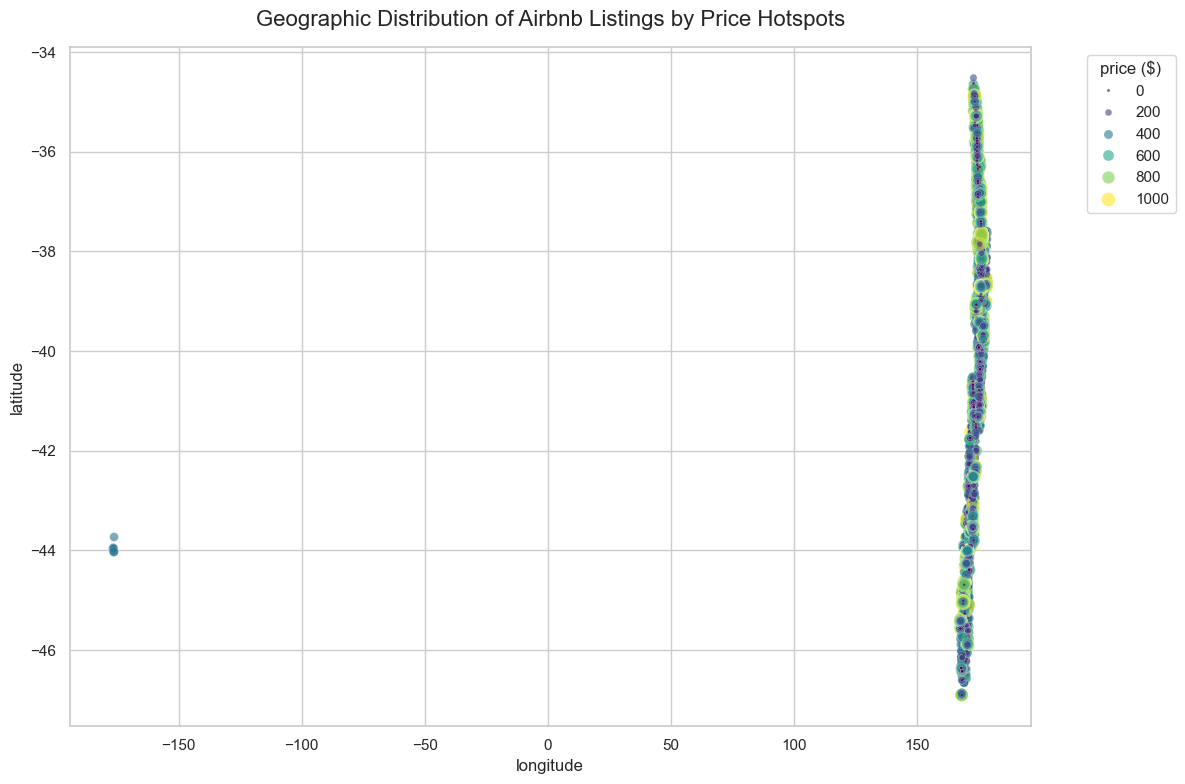

In [53]:
# If you map out the latitude and longitude do the high priceed listings cluster together in specific hubs like downtown or near costlines?

filtered_df = df[df['price']<=1000]

plt.figure(figsize=(12,8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data= filtered_df,
    x= 'longitude',
    y='latitude',
    hue='price',
    palette='viridis', 
    alpha=0.6,
    size='price',
    sizes=(5,100)
)

plt.title('Geographic Distribution of Airbnb Listings by Price Hotspots', fontsize=16, pad=15)
plt.xlabel('longitude', fontsize=12)
plt.ylabel('latitude', fontsize=12)

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='price ($)')
plt.tight_layout()

plt.show()

# Customer Satisfaction & Review Insights

In [56]:
# Does a higher number of reviews correlate with a lower or higher price?

correlation = df['price'].corr(df['number_of_reviews'])
print(f"The correlation coefficient between price and number of reviews is:{correlation:.4f}")

The correlation coefficient between price and number of reviews is:-0.0695


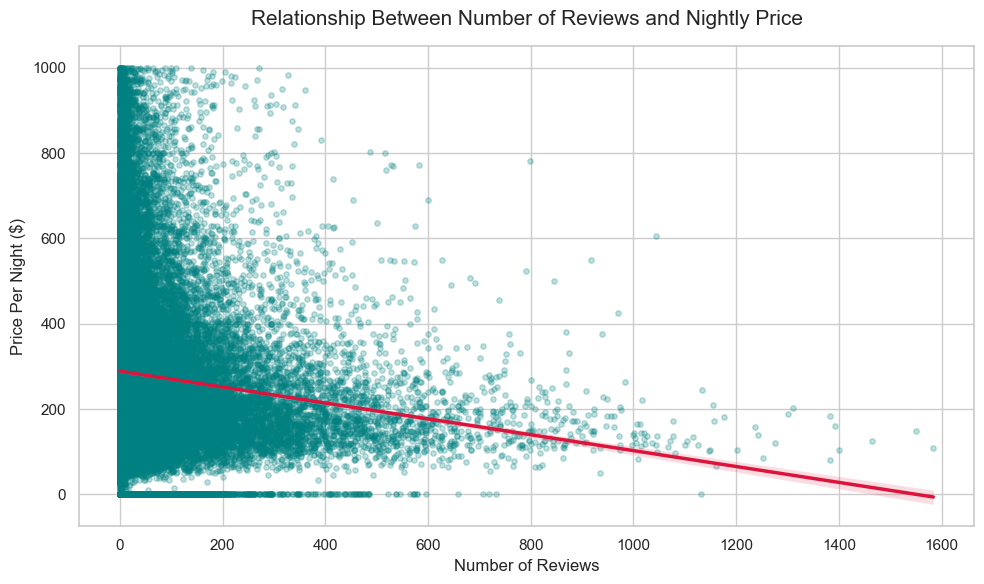

In [64]:
filtered_df = df[df['price'] <= 1000]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.regplot(
    data=filtered_df,
    x='number_of_reviews',
    y='price',
    scatter_kws={'alpha': 0.25, 'color': 'teal', 's': 15}, 
    line_kws={'color': 'crimson', 'linewidth': 2.5}         
)

plt.title('Relationship Between Number of Reviews and Nightly Price', fontsize=15, pad=15)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Price Per Night ($)', fontsize=12)
plt.tight_layout()


plt.show()

In [67]:
# Who are the top 5 hosts based on volume of reviews? Do these hosts tend to manage multiple properties?

host_reviews_analysis = df.groupby(['host_id', 'host_name']).agg(
    total_reviews=('number_of_reviews', 'sum'),
    properties_managed=('id','count') 
).reset_index()

top_5_reviewed_hosts = host_reviews_analysis.sort_values(by='total_reviews', ascending=False).head(5)

print("--- TOP 5 HOSTS BY VOLUME OF REVIEWS ---")
print(top_5_reviewed_hosts.to_string(index=False))

--- TOP 5 HOSTS BY VOLUME OF REVIEWS ---
    host_id           host_name  total_reviews  properties_managed
 84424371.0                 Ray          17532                 154
202585247.0               Ohana          15952                 150
352816357.0               Terry          11402                  94
 17084515.0             InnList          10825                 129
482671075.0 Care Property Stays          10317                 175


# Availabilty & Demand Analysis

In [71]:
# What percentage of listings are completely unavailable? Does this suggest they are permanently booked or inactive?

# --- Calculating the percentage of zero availability listings
zero_avail_count = (df['availability_365'] == 0).sum()

total_listings = len(df)
percentage_zero = (zero_avail_count / total_listings) *100

print(f"Total Listings with 0 availability : {zero_avail_count:,}")
print(f"Percentage of entire dataset:{percentage_zero:.2f}%");


# --- Testing the theroy whether they are booked or inactive

zero_avail_df = df[df['availability_365'] == 0]

review_summary = zero_avail_df['number_of_reviews'].describe()

print("--- REVIEW METRICS FOR '0 AVAILABILITY' PROPERTIES ---")

no_review_count = (zero_avail_df['number_of_reviews'] ==0).sum()
pct_no_reviews = (no_review_count / len(zero_avail_df)) *100

print(f"\nPercentage of the unvaialable lisitngs that have never received a single review: {pct_no_reviews:.2f}%")

Total Listings with 0 availability : 3,660
Percentage of entire dataset:7.19%
--- REVIEW METRICS FOR '0 AVAILABILITY' PROPERTIES ---

Percentage of the unvaialable lisitngs that have never received a single review: 8.88%


In [72]:
# Is there a relationship between a listing's minimum required stay nights and its price or availability?

# 1. Define a helper function to bucket the minimum nights
def segment_stay(nights):
    if nights <= 3:
        return 'Short-stay (1-3 nights)'
    elif nights < 30:
        return 'Medium-stay (4-29 nights)'
    else:
        return 'Long-stay (30+ nights)'

# 2. Apply the segmentation bucket mapping to the dataframe
df['stay_strategy'] = df['minimum_nights'].apply(segment_stay)

# 3. Group by strategy and aggregate the median pricing and availability metrics
strategy_analysis = df.groupby('stay_strategy').agg(
    listing_count=('id', 'count'),
    median_price=('price', 'median'),
    median_availability=('availability_365', 'median')
).reset_index()

print("--- STAY STRATEGY PERFORMANCE BREAKDOWN ---")
print(strategy_analysis.to_string(index=False))

--- STAY STRATEGY PERFORMANCE BREAKDOWN ---
            stay_strategy  listing_count  median_price  median_availability
   Long-stay (30+ nights)            147          71.0                207.0
Medium-stay (4-29 nights)           2641         359.0                149.0
  Short-stay (1-3 nights)          48144         240.0                230.0


In [73]:
# Compute the correlation coefficient between minimum_nights and other factors
price_corr = df['minimum_nights'].corr(df['price'])
avail_corr = df['minimum_nights'].corr(df['availability_365'])

print(f"Correlation between Minimum Nights and Price: {price_corr:.4f}")
print(f"Correlation between Minimum Nights and Availability: {avail_corr:.4f}")

Correlation between Minimum Nights and Price: 0.0066
Correlation between Minimum Nights and Availability: -0.0024
